# Phase 4 — Frozen Holdout Evaluation

This notebook applies the frozen early-warning detector to the holdout sample.

Frozen detector:

- Diagnostic: rolling excess kurtosis
- Diagnostic window: 63 trading days
- Historical z-score reference window: 252 observations
- Warning threshold: 2.0
- Warning reset period: 5 trading days
- Warning-to-collapse horizon: 126 trading days

The method is loaded from the frozen JSON configuration and is not modified in
this notebook.

Holdout evaluation includes:

- MKT_RF
- SMB
- HML
- RMW
- CMA
- Momentum collapse episodes other than the October 7, 2009 development event

Metrics:

- event-level precision,
- event-level recall,
- false-positive rate,
- detection rate,
- lead time, and
- warning frequency.

In [13]:
from google.colab import drive
drive.mount("/content/drive")
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(
    "/content/drive/MyDrive/When_Do_Factor_Premia_Break"
)

PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"

FACTOR_INPUT = (
    PROCESSED / "factor_returns_daily.parquet"
)

COLLAPSE_EVENTS_INPUT = (
    RESULTS / "collapse_events.csv"
)

FROZEN_CONFIG_INPUT = (
    RESULTS / "frozen_diagnostic_parameters.json"
)

print("Factor data:", FACTOR_INPUT)
print("Collapse events:", COLLAPSE_EVENTS_INPUT)
print("Frozen parameters:", FROZEN_CONFIG_INPUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Factor data: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/processed/factor_returns_daily.parquet
Collapse events: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/collapse_events.csv
Frozen parameters: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/frozen_diagnostic_parameters.json


In [14]:
factors = pd.read_parquet(
    FACTOR_INPUT
)

collapse_events = pd.read_csv(
    COLLAPSE_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
    ],
)

with open(
    FROZEN_CONFIG_INPUT,
    "r",
    encoding="utf-8",
) as file:
    frozen_config = json.load(file)

print("Factor shape:", factors.shape)
print("Collapse events:", len(collapse_events))
print("Configuration status:", frozen_config["status"])

Factor shape: (15833, 7)
Collapse events: 87
Configuration status: FROZEN


In [15]:
EXPECTED_FROZEN_VALUES = {
    "status": "FROZEN",
    "selected_rule_type": "single_diagnostic",
    "selected_diagnostics": [
        "excess_kurtosis"
    ],
    "diagnostic_window": 63,
    "zscore_reference_window": 252,
    "warning_threshold": 2.0,
    "warning_reset_days": 5,
    "warning_to_collapse_horizon_days": 126,
    "causal_standardization": True,
    "reference_shift_days": 1,
}

for key, expected_value in (
    EXPECTED_FROZEN_VALUES.items()
):
    actual_value = frozen_config.get(key)

    assert actual_value == expected_value, (
        f"Frozen parameter mismatch for {key}: "
        f"expected {expected_value!r}, "
        f"found {actual_value!r}"
    )

print("✓ Frozen configuration matches the approved specification")

DIAGNOSTIC_WINDOW = int(
    frozen_config["diagnostic_window"]
)

ZSCORE_REFERENCE_WINDOW = int(
    frozen_config["zscore_reference_window"]
)

WARNING_THRESHOLD = float(
    frozen_config["warning_threshold"]
)

WARNING_RESET_DAYS = int(
    frozen_config["warning_reset_days"]
)

WARNING_HORIZON = int(
    frozen_config[
        "warning_to_collapse_horizon_days"
    ]
)

DEVELOPMENT_FACTOR = frozen_config[
    "factor_used_for_development"
]

DEVELOPMENT_COLLAPSE_START = pd.Timestamp(
    frozen_config["development_collapse_start"]
)

✓ Frozen configuration matches the approved specification


In [16]:
FACTOR_COLUMNS = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM",
]

assert isinstance(
    factors.index,
    pd.DatetimeIndex,
)

assert factors.index.is_unique
assert factors.index.is_monotonic_increasing

assert set(FACTOR_COLUMNS).issubset(
    factors.columns
)

assert not factors[
    FACTOR_COLUMNS
].isna().any().any()

assert {
    "factor",
    "collapse_start",
    "collapse_end",
}.issubset(collapse_events.columns)

print("✓ Input datasets passed validation")

✓ Input datasets passed validation


In [17]:
development_event_mask = (
    (
        collapse_events["factor"]
        == DEVELOPMENT_FACTOR
    )
    & (
        collapse_events["collapse_start"]
        == DEVELOPMENT_COLLAPSE_START
    )
)

assert development_event_mask.sum() == 1

holdout_events = (
    collapse_events.loc[
        ~development_event_mask
    ]
    .copy()
    .sort_values(
        [
            "factor",
            "collapse_start",
        ]
    )
    .reset_index(drop=True)
)

print("Development events removed:", 1)
print("Holdout events retained:", len(holdout_events))

holdout_events.groupby(
    "factor"
).size().rename(
    "holdout_event_count"
).reindex(
    FACTOR_COLUMNS,
    fill_value=0,
)

Development events removed: 1
Holdout events retained: 86


,holdout_event_count
factor,
MKT_RF,17
SMB,16
HML,14
RMW,13
CMA,11
MOM,15


In [18]:
def rolling_excess_kurtosis(
    returns: pd.Series,
    window: int,
) -> pd.Series:
    """
    Calculate trailing Fisher excess kurtosis.
    """
    return returns.rolling(
        window=window,
        min_periods=window,
    ).kurt()

def historical_zscore(
    statistic: pd.Series,
    reference_window: int,
) -> pd.Series:
    """
    Standardize a statistic using only values dated t-1 and earlier.
    """
    prior_statistic = statistic.shift(1)

    historical_mean = prior_statistic.rolling(
        window=reference_window,
        min_periods=reference_window,
    ).mean()

    historical_std = prior_statistic.rolling(
        window=reference_window,
        min_periods=reference_window,
    ).std(ddof=1)

    zscore = (
        statistic - historical_mean
    ) / historical_std

    return zscore.replace(
        [np.inf, -np.inf],
        np.nan,
    )

def compute_frozen_fragility_score(
    returns: pd.Series,
    diagnostic_window: int,
    reference_window: int,
) -> pd.Series:
    """
    Compute the frozen excess-kurtosis fragility score.
    """
    raw_kurtosis = rolling_excess_kurtosis(
        returns,
        window=diagnostic_window,
    )

    score = historical_zscore(
        raw_kurtosis,
        reference_window=reference_window,
    )

    score.name = "excess_kurtosis_fragility"

    return score

In [19]:
def extract_warning_events(
    warning_condition: pd.Series,
    reset_days: int,
) -> pd.DatetimeIndex:
    """
    Extract distinct warning starts.

    A new warning cannot begin until the condition has remained false
    for at least `reset_days`.
    """
    condition = (
        warning_condition
        .fillna(False)
        .astype(bool)
    )

    warning_dates = []
    active_warning = False
    false_run_length = reset_days

    for date, is_warning in condition.items():
        if is_warning:
            if (
                not active_warning
                and false_run_length >= reset_days
            ):
                warning_dates.append(date)

            active_warning = True
            false_run_length = 0

        else:
            if active_warning:
                false_run_length += 1

                if false_run_length >= reset_days:
                    active_warning = False
            else:
                false_run_length = min(
                    false_run_length + 1,
                    reset_days,
                )

    return pd.DatetimeIndex(warning_dates)

In [20]:
fragility_scores = pd.DataFrame(
    {
        factor: compute_frozen_fragility_score(
            factors[factor],
            diagnostic_window=DIAGNOSTIC_WINDOW,
            reference_window=ZSCORE_REFERENCE_WINDOW,
        )
        for factor in FACTOR_COLUMNS
    },
    index=factors.index,
)

fragility_scores.dropna().head()

warning_conditions = (
    fragility_scores >= WARNING_THRESHOLD
)
warning_dates_by_factor = {
    factor: extract_warning_events(
        warning_conditions[factor],
        reset_days=WARNING_RESET_DAYS,
    )
    for factor in FACTOR_COLUMNS
}

warning_counts = pd.Series(
    {
        factor: len(dates)
        for factor, dates
        in warning_dates_by_factor.items()
    },
    name="warning_count",
)

warning_counts

,warning_count
MKT_RF,79
SMB,88
HML,90
RMW,100
CMA,85
MOM,94


In [21]:
test_factor = "HML"
test_returns = factors[test_factor].copy()

cutoff_position = int(
    len(test_returns) * 0.75
)

cutoff_date = test_returns.index[
    cutoff_position
]

altered_returns = test_returns.copy()

future_mask = (
    altered_returns.index > cutoff_date
)

altered_returns.loc[future_mask] = (
    altered_returns.loc[future_mask] * -8
    + 0.12
)

original_score = compute_frozen_fragility_score(
    test_returns,
    diagnostic_window=DIAGNOSTIC_WINDOW,
    reference_window=ZSCORE_REFERENCE_WINDOW,
)

altered_score = compute_frozen_fragility_score(
    altered_returns,
    diagnostic_window=DIAGNOSTIC_WINDOW,
    reference_window=ZSCORE_REFERENCE_WINDOW,
)

pd.testing.assert_series_equal(
    original_score.loc[:cutoff_date],
    altered_score.loc[:cutoff_date],
)

print(
    "✓ Future-data alteration did not change "
    f"{test_factor} scores through "
    f"{cutoff_date.date()}"
)

✓ Future-data alteration did not change HML scores through 2010-09-01


In [22]:
def evaluate_factor_events(
    factor: str,
    factor_index: pd.DatetimeIndex,
    warning_dates: pd.DatetimeIndex,
    events: pd.DataFrame,
    warning_horizon: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Match warning events to collapse events for one factor.

    Each warning and each collapse can be matched at most once.
    """
    factor_events = (
        events.loc[
            events["factor"] == factor
        ]
        .sort_values("collapse_start")
        .copy()
    )

    available_warnings = list(
        pd.DatetimeIndex(warning_dates)
    )

    event_records = []
    matched_warning_dates = set()

    for event in factor_events.itertuples(
        index=False
    ):
        collapse_start = event.collapse_start

        collapse_position = (
            factor_index.get_indexer(
                [collapse_start]
            )[0]
        )

        if collapse_position == -1:
            raise ValueError(
                f"{factor}: collapse date "
                f"{collapse_start.date()} "
                "not found in factor index"
            )

        window_start_position = max(
            0,
            collapse_position
            - warning_horizon,
        )

        warning_window_start = factor_index[
            window_start_position
        ]

        eligible_warnings = [
            warning_date
            for warning_date in available_warnings
            if (
                warning_window_start
                <= warning_date
                < collapse_start
            )
            and (
                warning_date
                not in matched_warning_dates
            )
        ]

        if eligible_warnings:
            # Use the earliest warning in the valid horizon.
            matched_warning = min(
                eligible_warnings
            )

            warning_position = (
                factor_index.get_indexer(
                    [matched_warning]
                )[0]
            )

            lead_time = (
                collapse_position
                - warning_position
            )

            detected = True
            matched_warning_dates.add(
                matched_warning
            )
        else:
            matched_warning = pd.NaT
            lead_time = np.nan
            detected = False

        event_records.append(
            {
                "factor": factor,
                "collapse_start": collapse_start,
                "collapse_end": event.collapse_end,
                "warning_window_start":
                    warning_window_start,
                "detected": detected,
                "matched_warning_date":
                    matched_warning,
                "lead_time_days": lead_time,
            }
        )

    event_results = pd.DataFrame(
        event_records
    )

    warning_records = []

    for warning_date in warning_dates:
        warning_records.append(
            {
                "factor": factor,
                "warning_date": warning_date,
                "classification": (
                    "true_positive"
                    if warning_date
                    in matched_warning_dates
                    else "false_positive"
                ),
            }
        )

    warning_results = pd.DataFrame(
        warning_records
    )

    return event_results, warning_results

In [23]:
all_event_results = []
all_warning_results = []

for factor in FACTOR_COLUMNS:
    factor_event_results, factor_warning_results = (
        evaluate_factor_events(
            factor=factor,
            factor_index=factors.index,
            warning_dates=warning_dates_by_factor[
                factor
            ],
            events=holdout_events,
            warning_horizon=WARNING_HORIZON,
        )
    )

    all_event_results.append(
        factor_event_results
    )

    all_warning_results.append(
        factor_warning_results
    )

holdout_event_results = pd.concat(
    all_event_results,
    ignore_index=True,
)

holdout_warning_results = pd.concat(
    all_warning_results,
    ignore_index=True,
)

holdout_event_results.head()
holdout_warning_results.head()


,factor,warning_date,classification
0,MKT_RF,1965-04-05,false_positive
1,MKT_RF,1965-06-30,false_positive
2,MKT_RF,1965-09-07,false_positive
3,MKT_RF,1966-12-21,false_positive
4,MKT_RF,1967-07-07,false_positive


In [24]:
matched_warnings = (
    holdout_event_results.loc[
        holdout_event_results[
            "matched_warning_date"
        ].notna(),
        [
            "factor",
            "matched_warning_date",
        ],
    ]
)

assert not matched_warnings.duplicated().any(), (
    "One factor-specific warning was matched "
    "to multiple collapse events."
)

assert not holdout_event_results[
    [
        "factor",
        "collapse_start",
    ]
].duplicated().any(), (
    "A factor collapse event appears more than once."
)

assert (
    holdout_event_results.loc[
        holdout_event_results["detected"],
        "lead_time_days",
    ]
    .between(
        1,
        WARNING_HORIZON,
    )
    .all()
), (
    "Detected events contain invalid lead times."
)

assert (
    holdout_event_results.loc[
        ~holdout_event_results["detected"],
        "matched_warning_date",
    ]
    .isna()
    .all()
), (
    "A missed collapse has a matched warning date."
)

assert (
    holdout_event_results.loc[
        holdout_event_results["detected"],
        "matched_warning_date",
    ]
    .notna()
    .all()
), (
    "A detected collapse is missing its warning date."
)

print("✓ Warning-event matching passed validation")

✓ Warning-event matching passed validation


In [25]:
def safe_divide(
    numerator: float,
    denominator: float,
) -> float:
    if denominator == 0:
        return np.nan

    return numerator / denominator

factor_metrics = []

for factor in FACTOR_COLUMNS:
    event_subset = holdout_event_results.loc[
        holdout_event_results["factor"]
        == factor
    ]

    warning_subset = holdout_warning_results.loc[
        holdout_warning_results["factor"]
        == factor
    ]

    true_positive_warnings = int(
        (
            warning_subset["classification"]
            == "true_positive"
        ).sum()
    )

    false_positive_warnings = int(
        (
            warning_subset["classification"]
            == "false_positive"
        ).sum()
    )

    detected_events = int(
        event_subset["detected"].sum()
    )

    total_events = len(event_subset)
    total_warnings = len(warning_subset)

    precision = safe_divide(
        true_positive_warnings,
        total_warnings,
    )

    recall = safe_divide(
        detected_events,
        total_events,
    )

    false_positive_rate = safe_divide(
        false_positive_warnings,
        total_warnings,
    )

    detected_lead_times = (
        event_subset.loc[
            event_subset["detected"],
            "lead_time_days",
        ]
    )

    sample_years = (
        factors.index[-1]
        - factors.index[0]
    ).days / 365.25

    factor_metrics.append(
        {
            "factor": factor,
            "collapse_events": total_events,
            "detected_events": detected_events,
            "missed_events":
                total_events - detected_events,
            "warning_events": total_warnings,
            "true_positive_warnings":
                true_positive_warnings,
            "false_positive_warnings":
                false_positive_warnings,
            "precision": precision,
            "recall": recall,
            "detection_rate": recall,
            "false_positive_rate":
                false_positive_rate,
            "median_lead_time_days":
                detected_lead_times.median(),
            "mean_lead_time_days":
                detected_lead_times.mean(),
            "minimum_lead_time_days":
                detected_lead_times.min(),
            "maximum_lead_time_days":
                detected_lead_times.max(),
            "warnings_per_year":
                total_warnings / sample_years,
        }
    )

factor_metrics = pd.DataFrame(
    factor_metrics
)

factor_metrics


,factor,collapse_events,detected_events,missed_events,warning_events,true_positive_warnings,false_positive_warnings,precision,recall,detection_rate,false_positive_rate,median_lead_time_days,mean_lead_time_days,minimum_lead_time_days,maximum_lead_time_days,warnings_per_year
0,MKT_RF,17,6,11,79,6,73,0.075949,0.352941,0.352941,0.924051,64.0,60.500000,16.0,102.0,1.255756
1,SMB,16,10,6,88,10,78,0.113636,0.625000,0.625000,0.886364,78.0,66.900000,6.0,113.0,1.398816
2,HML,14,6,8,90,6,84,0.066667,0.428571,0.428571,0.933333,72.5,68.333333,17.0,116.0,1.430608
3,RMW,13,8,5,100,8,92,0.080000,0.615385,0.615385,0.920000,51.0,67.250000,21.0,125.0,1.589564
4,CMA,11,4,7,85,4,81,0.047059,0.363636,0.363636,0.952941,78.5,76.750000,43.0,107.0,1.351129
5,MOM,15,8,7,94,8,86,0.085106,0.533333,0.533333,0.914894,65.5,64.750000,11.0,106.0,1.494190


In [26]:
total_holdout_events = len(
    holdout_event_results
)

total_detected_events = int(
    holdout_event_results[
        "detected"
    ].sum()
)

total_warnings = len(
    holdout_warning_results
)

total_true_positive_warnings = int(
    (
        holdout_warning_results[
            "classification"
        ]
        == "true_positive"
    ).sum()
)

total_false_positive_warnings = int(
    (
        holdout_warning_results[
            "classification"
        ]
        == "false_positive"
    ).sum()
)

pooled_precision = safe_divide(
    total_true_positive_warnings,
    total_warnings,
)

pooled_recall = safe_divide(
    total_detected_events,
    total_holdout_events,
)

pooled_false_positive_rate = safe_divide(
    total_false_positive_warnings,
    total_warnings,
)

detected_lead_times = (
    holdout_event_results.loc[
        holdout_event_results["detected"],
        "lead_time_days",
    ]
)

pooled_metrics = pd.DataFrame(
    [
        {
            "holdout_collapse_events":
                total_holdout_events,
            "detected_events":
                total_detected_events,
            "missed_events":
                total_holdout_events
                - total_detected_events,
            "warning_events":
                total_warnings,
            "true_positive_warnings":
                total_true_positive_warnings,
            "false_positive_warnings":
                total_false_positive_warnings,
            "precision":
                pooled_precision,
            "recall":
                pooled_recall,
            "detection_rate":
                pooled_recall,
            "false_positive_rate":
                pooled_false_positive_rate,
            "median_lead_time_days":
                detected_lead_times.median(),
            "mean_lead_time_days":
                detected_lead_times.mean(),
        }
    ]
)

pooled_metrics

,holdout_collapse_events,detected_events,missed_events,warning_events,true_positive_warnings,false_positive_warnings,precision,recall,detection_rate,false_positive_rate,median_lead_time_days,mean_lead_time_days
0,86,42,44,536,42,494,0.078358,0.488372,0.488372,0.921642,66.0,66.785714


## Metric interpretation

Precision is calculated at the warning-event level:

\[
\text{Precision}
=
\frac{\text{matched warning events}}
{\text{all warning events}}
\]

Recall is calculated at the collapse-event level:

\[
\text{Recall}
=
\frac{\text{collapse events with a matched advance warning}}
{\text{all collapse events}}
\]

The reported false-positive rate is the share of warning events that were not
matched to a collapse beginning within the frozen 126-trading-day horizon.

Because collapse episodes may occur close together, each warning and collapse
event is matched at most once.

In [27]:
detected_events = (
    holdout_event_results.loc[
        holdout_event_results["detected"]
    ]
    .sort_values(
        [
            "factor",
            "collapse_start",
        ]
    )
)

missed_events = (
    holdout_event_results.loc[
        ~holdout_event_results["detected"]
    ]
    .sort_values(
        [
            "factor",
            "collapse_start",
        ]
    )
)

print("Detected holdout events:")
display(detected_events)

print("\nMissed holdout events:")
display(missed_events)

Detected holdout events:


,factor,collapse_start,collapse_end,warning_window_start,detected,matched_warning_date,lead_time_days
63,CMA,1999-01-15,1999-02-01,1998-07-17,True,1998-08-31,95.0
65,CMA,2004-11-03,2004-11-16,2004-05-05,True,2004-09-02,43.0
67,CMA,2014-03-13,2014-03-21,2013-09-11,True,2013-10-08,107.0
70,CMA,2023-12-27,2024-01-22,2023-06-28,True,2023-09-28,62.0
34,HML,1972-01-06,1972-01-20,1971-07-09,True,1971-08-02,110.0
35,HML,1978-05-11,1978-06-15,1977-11-09,True,1978-04-18,17.0
36,HML,1980-07-09,1980-12-05,1980-01-09,True,1980-01-25,114.0
38,HML,1989-11-08,1989-12-15,1989-05-11,True,1989-10-13,18.0
43,HML,1999-10-01,1999-10-21,1999-04-05,True,1999-04-19,116.0
46,HML,2007-07-05,2008-01-28,2007-01-03,True,2007-05-15,35.0



Missed holdout events:


,factor,collapse_start,collapse_end,warning_window_start,detected,matched_warning_date,lead_time_days
60,CMA,1980-09-17,1981-01-02,1980-03-19,False,NaT,NaN
61,CMA,1991-02-15,1991-02-25,1990-08-17,False,NaT,NaN
62,CMA,1991-07-22,1992-01-15,1991-01-21,False,NaT,NaN
64,CMA,1999-10-06,1999-10-13,1999-04-08,False,NaT,NaN
66,CMA,2004-11-24,2005-06-01,2004-05-26,False,NaT,NaN
68,CMA,2015-04-23,2015-05-21,2014-10-21,False,NaT,NaN
69,CMA,2015-07-10,2015-08-05,2015-01-08,False,NaT,NaN
33,HML,1969-12-10,1970-01-22,1969-06-11,False,NaT,NaN
37,HML,1986-06-12,1986-06-23,1985-12-11,False,NaT,NaN
39,HML,1990-01-04,1990-01-24,1989-07-06,False,NaT,NaN


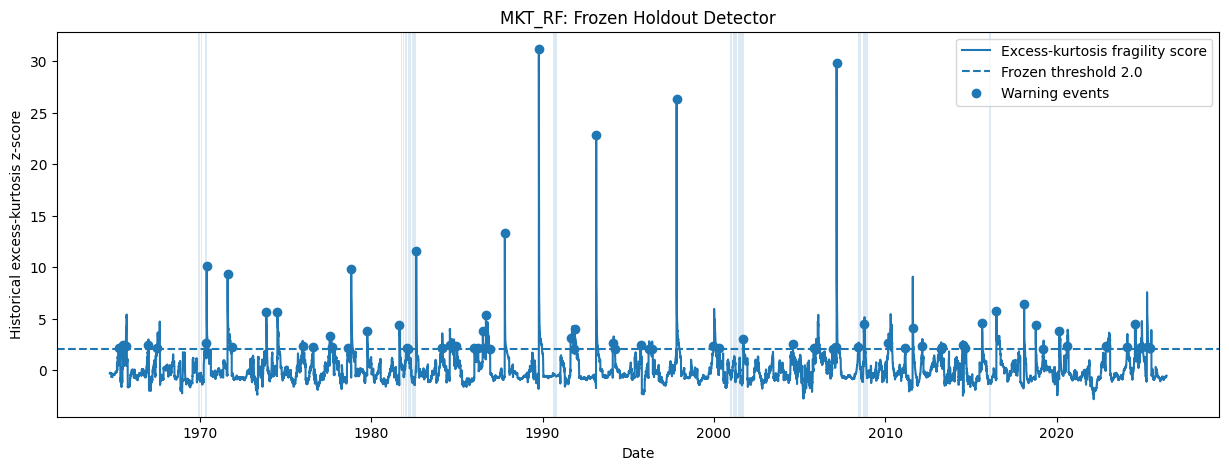

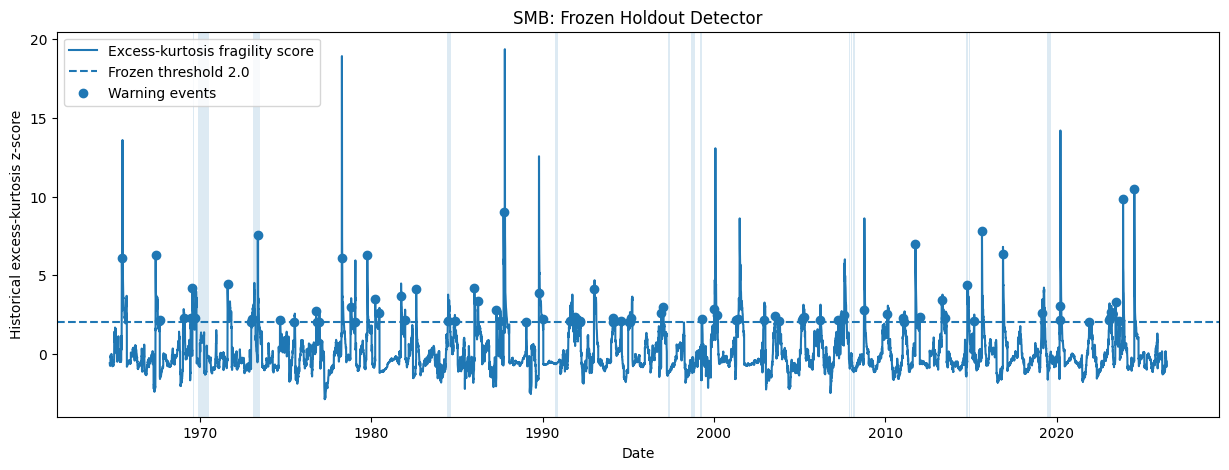

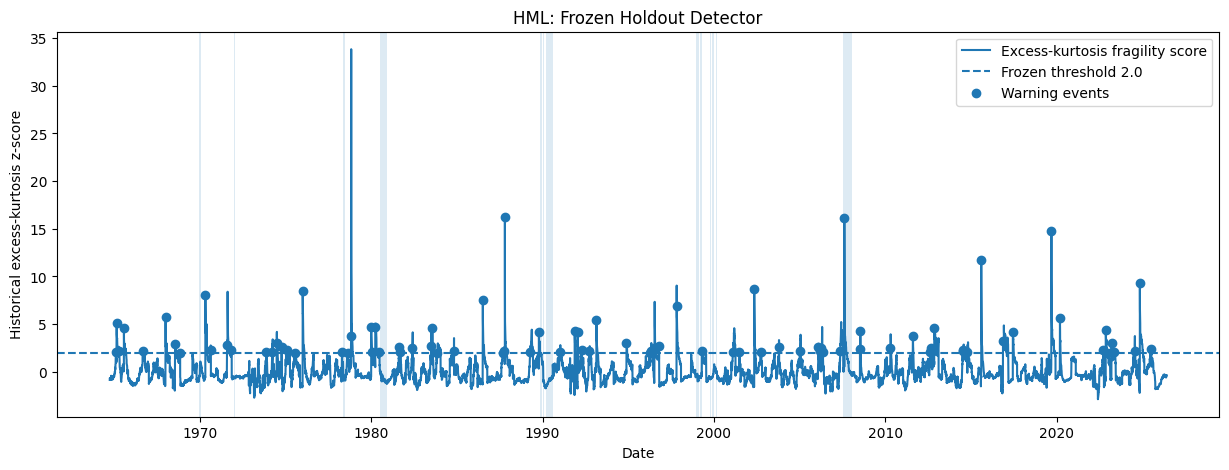

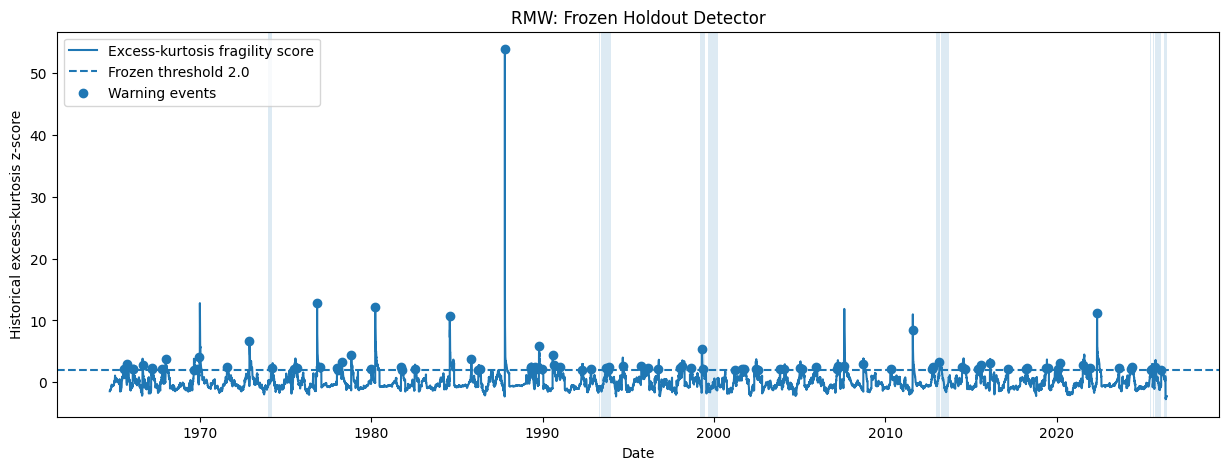

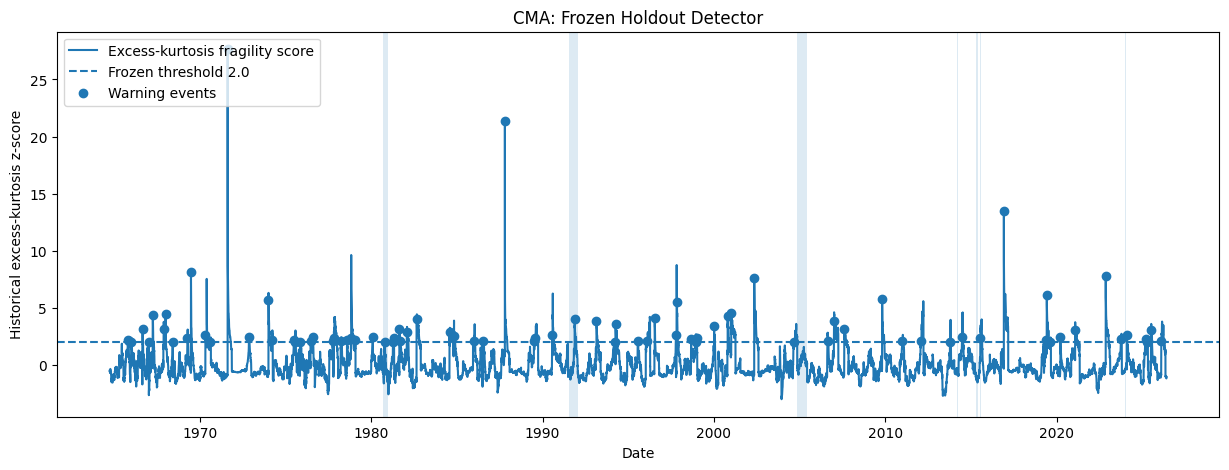

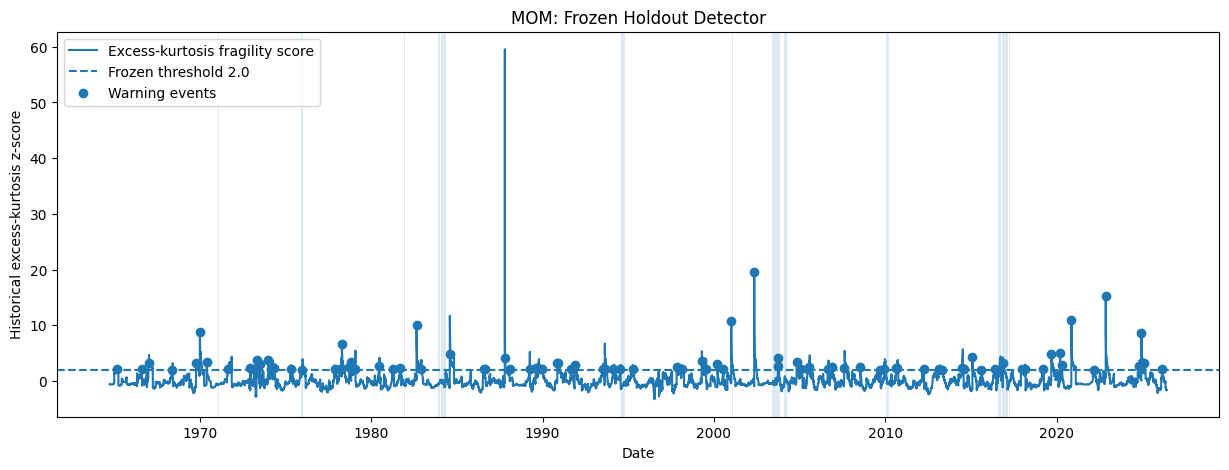

In [28]:
for factor in FACTOR_COLUMNS:
    fig, ax = plt.subplots(
        figsize=(15, 5)
    )

    score = fragility_scores[factor]

    ax.plot(
        score.index,
        score,
        label="Excess-kurtosis fragility score",
    )

    ax.axhline(
        WARNING_THRESHOLD,
        linestyle="--",
        label=(
            f"Frozen threshold "
            f"{WARNING_THRESHOLD}"
        ),
    )

    factor_warnings = warning_dates_by_factor[
        factor
    ]

    ax.scatter(
        factor_warnings,
        score.reindex(factor_warnings),
        marker="o",
        label="Warning events",
    )

    factor_events = holdout_event_results.loc[
        holdout_event_results["factor"]
        == factor
    ]

    for event in factor_events.itertuples(
        index=False
    ):
        ax.axvspan(
            event.collapse_start,
            event.collapse_end,
            alpha=0.15,
        )

    ax.set_title(
        f"{factor}: Frozen Holdout Detector"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(
        "Historical excess-kurtosis z-score"
    )

    ax.legend()
    plt.show()

In [29]:
FRAGILITY_OUTPUT = (
    RESULTS
    / "holdout_fragility_scores.parquet"
)

EVENT_RESULTS_OUTPUT = (
    RESULTS
    / "holdout_event_results.csv"
)

WARNING_RESULTS_OUTPUT = (
    RESULTS
    / "holdout_warning_results.csv"
)

FACTOR_METRICS_OUTPUT = (
    RESULTS
    / "holdout_factor_metrics.csv"
)

POOLED_METRICS_OUTPUT = (
    RESULTS
    / "holdout_pooled_metrics.csv"
)

fragility_scores.to_parquet(
    FRAGILITY_OUTPUT
)

holdout_event_results.to_csv(
    EVENT_RESULTS_OUTPUT,
    index=False,
)

holdout_warning_results.to_csv(
    WARNING_RESULTS_OUTPUT,
    index=False,
)

factor_metrics.to_csv(
    FACTOR_METRICS_OUTPUT,
    index=False,
)

pooled_metrics.to_csv(
    POOLED_METRICS_OUTPUT,
    index=False,
)

print("✓ Holdout outputs saved")

✓ Holdout outputs saved


In [30]:
event_results_reload = pd.read_csv(
    EVENT_RESULTS_OUTPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
        "warning_window_start",
        "matched_warning_date",
    ],
)

factor_metrics_reload = pd.read_csv(
    FACTOR_METRICS_OUTPUT
)

pooled_metrics_reload = pd.read_csv(
    POOLED_METRICS_OUTPUT
)

pd.testing.assert_frame_equal(
    holdout_event_results.reset_index(
        drop=True
    ),
    event_results_reload.reset_index(
        drop=True
    ),
    check_dtype=False,
)

pd.testing.assert_frame_equal(
    factor_metrics.reset_index(drop=True),
    factor_metrics_reload.reset_index(
        drop=True
    ),
    check_dtype=False,
)

pd.testing.assert_frame_equal(
    pooled_metrics.reset_index(drop=True),
    pooled_metrics_reload.reset_index(
        drop=True
    ),
    check_dtype=False,
)

print("✓ Saved holdout results reload correctly")

✓ Saved holdout results reload correctly


In [31]:
print("=" * 70)
print("FROZEN HOLDOUT EVALUATION COMPLETE")
print("=" * 70)

print(
    "Frozen diagnostic:",
    frozen_config["selected_diagnostics"][0],
)

print(
    "Threshold:",
    WARNING_THRESHOLD,
)

print(
    "Holdout collapse events:",
    total_holdout_events,
)

print(
    "Detected events:",
    total_detected_events,
)

print(
    "Missed events:",
    total_holdout_events
    - total_detected_events,
)

print(
    "Warning events:",
    total_warnings,
)

print(
    "Precision:",
    round(pooled_precision, 4),
)

print(
    "Recall:",
    round(pooled_recall, 4),
)

print(
    "False-positive rate:",
    round(pooled_false_positive_rate, 4),
)

print(
    "Median lead time:",
    detected_lead_times.median(),
)

print("\nSaved files:")

for path in [
    FRAGILITY_OUTPUT,
    EVENT_RESULTS_OUTPUT,
    WARNING_RESULTS_OUTPUT,
    FACTOR_METRICS_OUTPUT,
    POOLED_METRICS_OUTPUT,
]:
    print(" -", path.name)

FROZEN HOLDOUT EVALUATION COMPLETE
Frozen diagnostic: excess_kurtosis
Threshold: 2.0
Holdout collapse events: 86
Detected events: 42
Missed events: 44
Warning events: 536
Precision: 0.0784
Recall: 0.4884
False-positive rate: 0.9216
Median lead time: 66.0

Saved files:
 - holdout_fragility_scores.parquet
 - holdout_event_results.csv
 - holdout_warning_results.csv
 - holdout_factor_metrics.csv
 - holdout_pooled_metrics.csv


# Appendix A — Refining Warning Classification

The primary evaluation classifies every unmatched warning as a false positive.

However, some unmatched warnings may occur substantially earlier than the
predefined 126-trading-day warning horizon before a later collapse.

This appendix separates unmatched warnings into:

1. True positives
2. Early warnings
3. False positives

This appendix does **not** modify:

- the frozen detector,
- the warning threshold,
- the warning horizon,
- the collapse definition, or
- any reported primary metrics.

It provides additional interpretation only.

✓ Appendix warning classifications passed validation

Appendix warning classifications by factor:


appendix_classification,true_positive,duplicate_in_horizon,extended_early_warning,too_early_to_attribute,post_collapse_warning,terminal_false_positive,total_warning_events,primary_precision,warning_within_primary_horizon_share,warning_within_one_year_share,too_early_share,terminal_false_positive_share
factor,,,,,,,,,,,,
MKT_RF,6,0,3,54,3,13,79,0.075949,0.075949,0.113924,0.683544,0.164557
SMB,10,2,4,61,3,8,88,0.113636,0.136364,0.181818,0.693182,0.090909
HML,6,3,2,52,1,26,90,0.066667,0.100000,0.122222,0.577778,0.288889
RMW,8,1,4,81,6,0,100,0.080000,0.090000,0.130000,0.810000,0.000000
CMA,4,2,3,67,3,6,85,0.047059,0.070588,0.105882,0.788235,0.070588
MOM,8,2,7,62,2,13,94,0.085106,0.106383,0.180851,0.659574,0.138298



Pooled appendix summary:


,warning_events,true_positive_warnings,duplicate_in_horizon_warnings,extended_early_warnings,too_early_to_attribute,post_collapse_warnings,terminal_false_positives,primary_precision,warning_within_primary_horizon_share,warning_within_one_year_share,too_early_share,terminal_false_positive_share,primary_warning_horizon_days,extended_warning_horizon_days
0,536,42,10,23,377,18,66,0.078358,0.097015,0.139925,0.703358,0.123134,126,252



Lead-time summary by appendix class:


,count,mean,median,minimum,maximum
appendix_classification,,,,,
true_positive,42,66.785714,66.0,6.0,125.0
duplicate_in_horizon,10,27.000000,22.0,7.0,70.0
extended_early_warning,23,185.956522,173.0,131.0,251.0
too_early_to_attribute,377,1263.748011,1047.0,257.0,4821.0



Primary and appendix factor metrics:


,factor,collapse_events,detected_events,missed_events,warning_events,true_positive_warnings,false_positive_warnings,precision,recall,detection_rate,...,extended_early_warning,too_early_to_attribute,post_collapse_warning,terminal_false_positive,total_warning_events,primary_precision,warning_within_primary_horizon_share,warning_within_one_year_share,too_early_share,terminal_false_positive_share
0,MKT_RF,17,6,11,79,6,73,0.075949,0.352941,0.352941,...,3,54,3,13,79,0.075949,0.075949,0.113924,0.683544,0.164557
1,SMB,16,10,6,88,10,78,0.113636,0.625000,0.625000,...,4,61,3,8,88,0.113636,0.136364,0.181818,0.693182,0.090909
2,HML,14,6,8,90,6,84,0.066667,0.428571,0.428571,...,2,52,1,26,90,0.066667,0.100000,0.122222,0.577778,0.288889
3,RMW,13,8,5,100,8,92,0.080000,0.615385,0.615385,...,4,81,6,0,100,0.080000,0.090000,0.130000,0.810000,0.000000
4,CMA,11,4,7,85,4,81,0.047059,0.363636,0.363636,...,3,67,3,6,85,0.047059,0.070588,0.105882,0.788235,0.070588
5,MOM,15,8,7,94,8,86,0.085106,0.533333,0.533333,...,7,62,2,13,94,0.085106,0.106383,0.180851,0.659574,0.138298


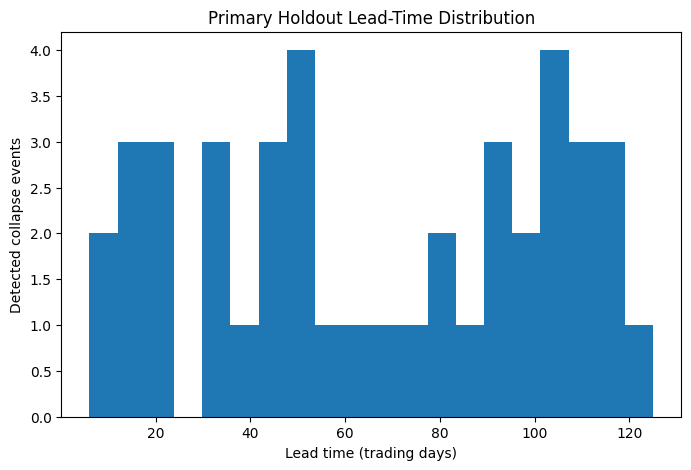

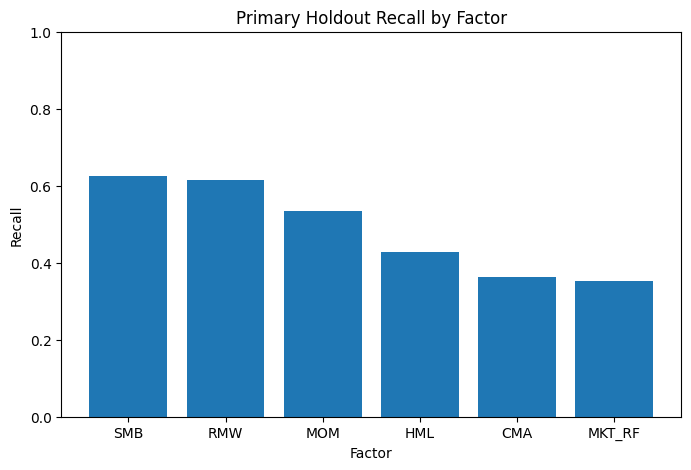

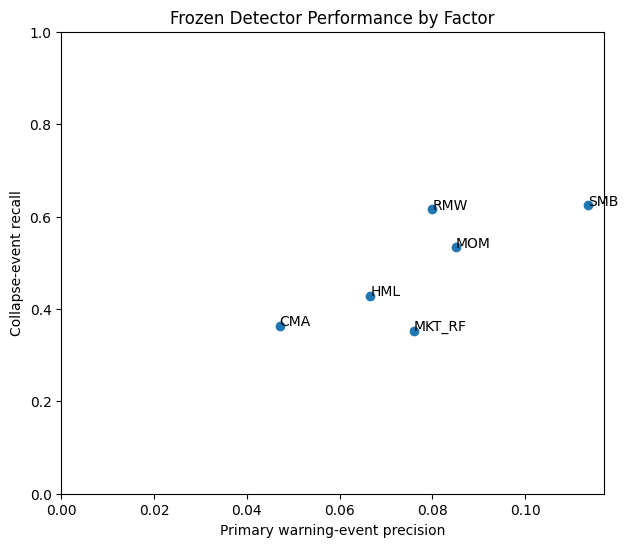

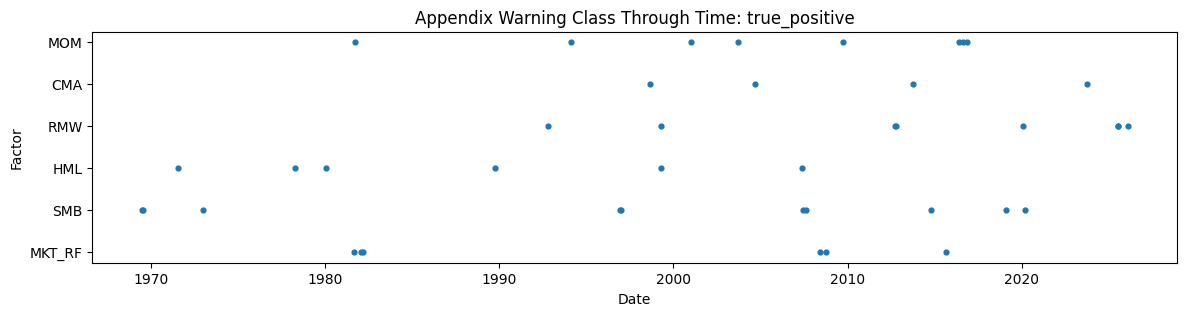

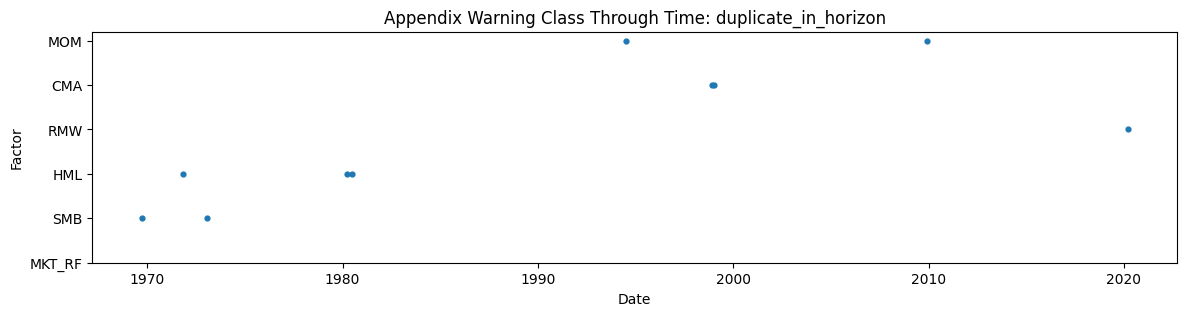

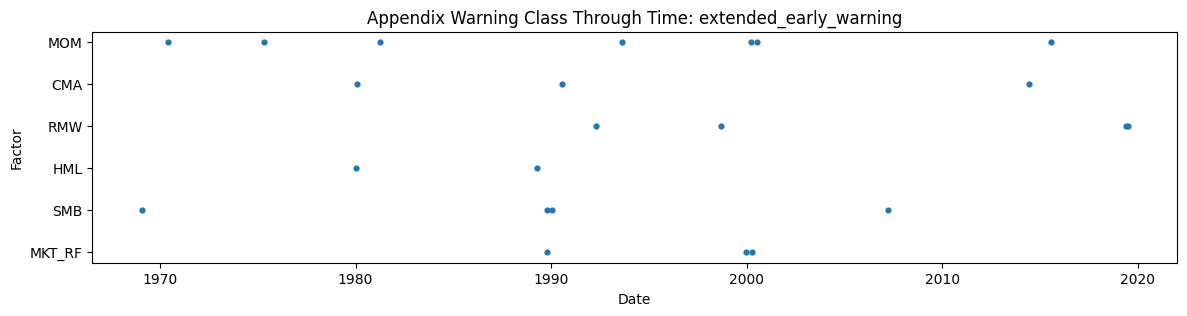

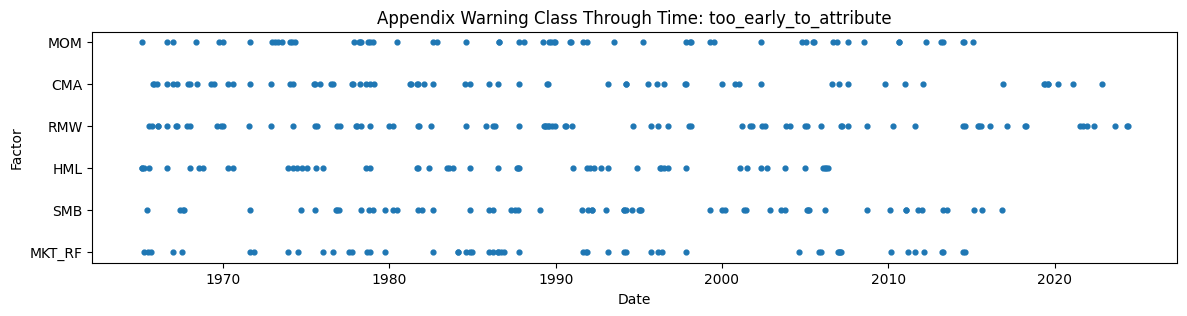

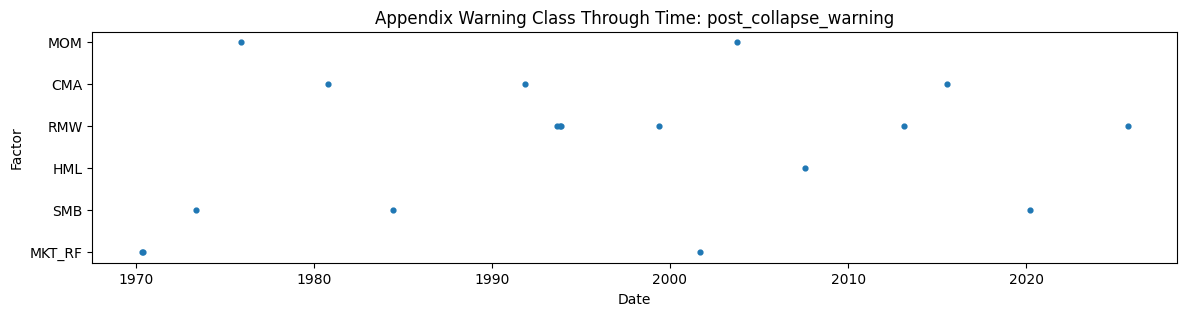

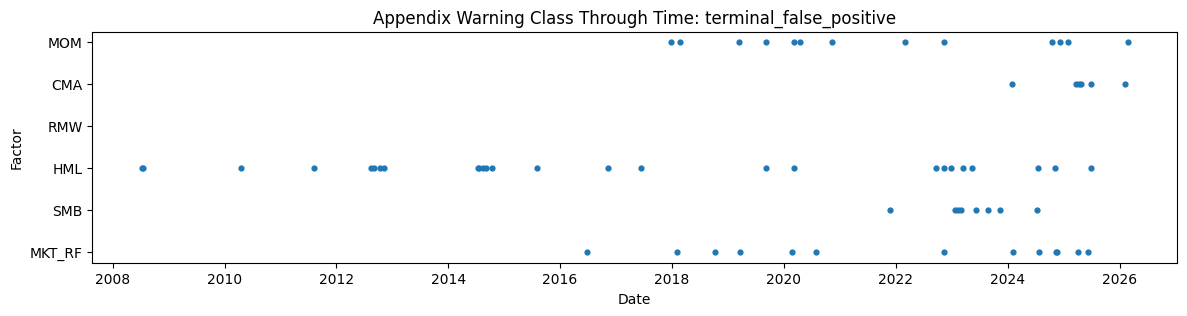

✓ Appendix warning classifications saved and reloaded correctly
✓ Appendix factor summary saved and reloaded correctly
✓ Appendix pooled summary saved and reloaded correctly
✓ Appendix lead-time summary saved and reloaded correctly
✓ Appendix factor performance saved and reloaded correctly

✓ All appendix outputs passed round-trip verification

APPENDIX A — WARNING CLASSIFICATION REFINEMENT COMPLETE
Primary detector and primary metrics were not modified.
Primary horizon: 126 trading days
Extended exploratory horizon: 252 trading days
Total warning events: 536

Classification counts:
true_positive                  42
duplicate_in_horizon           10
extended_early_warning         23
too_early_to_attribute         377
post_collapse_warning          18
terminal_false_positive        66

Saved appendix files:
 - appendix_warning_classifications.csv
 - appendix_warning_summary_by_factor.csv
 - appendix_warning_summary_pooled.csv
 - appendix_warning_lead_time_summary.csv
 - appendix_factor_

In [35]:
# ============================================================
# APPENDIX A — EXPLORATORY WARNING CLASSIFICATION REFINEMENT
# ============================================================
#
# This appendix does NOT modify:
# - the frozen detector,
# - the frozen threshold,
# - the 126-day primary evaluation horizon,
# - the collapse definition,
# - holdout_event_results,
# - holdout_warning_results,
# - factor_metrics, or
# - pooled_metrics.
#
# It creates separate appendix-only classifications:
#
# 1. true_positive
#    Formally matched to a collapse within 126 trading days.
#
# 2. duplicate_in_horizon
#    Also occurred within 126 trading days of a collapse, but another
#    warning was already matched to that collapse.
#
# 3. extended_early_warning
#    Occurred 127–252 trading days before the next collapse.
#
# 4. too_early_to_attribute
#    Occurred more than 252 trading days before the next collapse.
#
# 5. post_collapse_warning
#    Occurred during an active collapse episode.
#
# 6. terminal_false_positive
#    No later holdout collapse occurred before the sample ended.


# ------------------------------------------------------------
# A1. Validate required objects and constants
# ------------------------------------------------------------

required_objects = {
    "factors": factors,
    "holdout_events": holdout_events,
    "holdout_event_results": holdout_event_results,
    "holdout_warning_results": holdout_warning_results,
    "factor_metrics": factor_metrics,
    "pooled_metrics": pooled_metrics,
    "frozen_config": frozen_config,
}

for object_name, object_value in required_objects.items():
    assert object_value is not None, (
        f"Required object {object_name!r} is missing."
    )

assert isinstance(factors.index, pd.DatetimeIndex)
assert factors.index.is_unique
assert factors.index.is_monotonic_increasing

PRIMARY_WARNING_HORIZON = int(
    frozen_config["warning_to_collapse_horizon_days"]
)

EXTENDED_WARNING_HORIZON = 252

assert PRIMARY_WARNING_HORIZON == int(WARNING_HORIZON)
assert EXTENDED_WARNING_HORIZON > PRIMARY_WARNING_HORIZON

APPENDIX_CLASSES = [
    "true_positive",
    "duplicate_in_horizon",
    "extended_early_warning",
    "too_early_to_attribute",
    "post_collapse_warning",
    "terminal_false_positive",
]

APPENDIX_OUTPUT_DIRECTORY = RESULTS


# ------------------------------------------------------------
# A2. Trading-day distance helper
# ------------------------------------------------------------

def trading_day_distance(
    index: pd.DatetimeIndex,
    earlier_date: pd.Timestamp,
    later_date: pd.Timestamp,
) -> int:
    """
    Return the number of trading-index positions between two dates.

    A positive result means later_date occurs after earlier_date.
    """
    earlier_date = pd.Timestamp(earlier_date)
    later_date = pd.Timestamp(later_date)

    earlier_position = index.get_indexer(
        [earlier_date]
    )[0]

    later_position = index.get_indexer(
        [later_date]
    )[0]

    if earlier_position == -1:
        raise ValueError(
            f"Earlier date {earlier_date.date()} "
            "is not in the factor index."
        )

    if later_position == -1:
        raise ValueError(
            f"Later date {later_date.date()} "
            "is not in the factor index."
        )

    return int(
        later_position - earlier_position
    )


# ------------------------------------------------------------
# A3. Build factor-specific event and match lookups
# ------------------------------------------------------------

events_by_factor = {
    factor: (
        holdout_events.loc[
            holdout_events["factor"] == factor
        ]
        .sort_values("collapse_start")
        .reset_index(drop=True)
        .copy()
    )
    for factor in FACTOR_COLUMNS
}

matched_pairs = (
    holdout_event_results.loc[
        holdout_event_results[
            "matched_warning_date"
        ].notna(),
        [
            "factor",
            "matched_warning_date",
            "collapse_start",
        ],
    ]
    .copy()
)

matched_pairs["matched_warning_date"] = pd.to_datetime(
    matched_pairs["matched_warning_date"]
)

matched_pairs["collapse_start"] = pd.to_datetime(
    matched_pairs["collapse_start"]
)

matched_pair_lookup = {
    (
        row.factor,
        pd.Timestamp(row.matched_warning_date),
    ): pd.Timestamp(row.collapse_start)
    for row in matched_pairs.itertuples(
        index=False
    )
}


# ------------------------------------------------------------
# A4. Classify one warning
# ------------------------------------------------------------

def classify_appendix_warning(
    factor: str,
    warning_date: pd.Timestamp,
    factor_events: pd.DataFrame,
    matched_lookup: dict,
    factor_index: pd.DatetimeIndex,
    primary_horizon: int,
    extended_horizon: int,
) -> dict:
    """
    Add an appendix-only interpretation to one frozen warning.

    This function does not alter the primary one-to-one matching.
    """
    warning_date = pd.Timestamp(
        warning_date
    )

    matched_key = (
        factor,
        warning_date,
    )

    # Primary matched true positive.
    if matched_key in matched_lookup:
        matched_collapse = matched_lookup[
            matched_key
        ]

        lead_time = trading_day_distance(
            factor_index,
            warning_date,
            matched_collapse,
        )

        return {
            "appendix_classification":
                "true_positive",
            "reference_collapse_start":
                matched_collapse,
            "appendix_lead_time_days":
                lead_time,
            "inside_active_collapse":
                False,
            "within_primary_horizon":
                True,
            "within_extended_horizon":
                True,
        }

    # Warning during an already active collapse.
    active_events = factor_events.loc[
        (
            factor_events["collapse_start"]
            <= warning_date
        )
        & (
            factor_events["collapse_end"]
            >= warning_date
        )
    ]

    if not active_events.empty:
        active_event = active_events.iloc[0]

        return {
            "appendix_classification":
                "post_collapse_warning",
            "reference_collapse_start":
                pd.Timestamp(
                    active_event["collapse_start"]
                ),
            "appendix_lead_time_days":
                0,
            "inside_active_collapse":
                True,
            "within_primary_horizon":
                False,
            "within_extended_horizon":
                False,
        }

    # Locate the next future holdout collapse.
    future_events = factor_events.loc[
        factor_events["collapse_start"]
        > warning_date
    ]

    if future_events.empty:
        return {
            "appendix_classification":
                "terminal_false_positive",
            "reference_collapse_start":
                pd.NaT,
            "appendix_lead_time_days":
                np.nan,
            "inside_active_collapse":
                False,
            "within_primary_horizon":
                False,
            "within_extended_horizon":
                False,
        }

    next_event = future_events.iloc[0]

    next_collapse = pd.Timestamp(
        next_event["collapse_start"]
    )

    lead_time = trading_day_distance(
        factor_index,
        warning_date,
        next_collapse,
    )

    if lead_time <= primary_horizon:
        classification = (
            "duplicate_in_horizon"
        )
        within_primary_horizon = True
        within_extended_horizon = True

    elif lead_time <= extended_horizon:
        classification = (
            "extended_early_warning"
        )
        within_primary_horizon = False
        within_extended_horizon = True

    else:
        classification = (
            "too_early_to_attribute"
        )
        within_primary_horizon = False
        within_extended_horizon = False

    return {
        "appendix_classification":
            classification,
        "reference_collapse_start":
            next_collapse,
        "appendix_lead_time_days":
            lead_time,
        "inside_active_collapse":
            False,
        "within_primary_horizon":
            within_primary_horizon,
        "within_extended_horizon":
            within_extended_horizon,
    }


# ------------------------------------------------------------
# A5. Reclassify all warnings in a separate DataFrame
# ------------------------------------------------------------

appendix_warning_records = []

for warning in holdout_warning_results.itertuples(
    index=False
):
    factor = warning.factor

    warning_date = pd.Timestamp(
        warning.warning_date
    )

    classification_result = (
        classify_appendix_warning(
            factor=factor,
            warning_date=warning_date,
            factor_events=events_by_factor[
                factor
            ],
            matched_lookup=matched_pair_lookup,
            factor_index=factors.index,
            primary_horizon=(
                PRIMARY_WARNING_HORIZON
            ),
            extended_horizon=(
                EXTENDED_WARNING_HORIZON
            ),
        )
    )

    appendix_warning_records.append(
        {
            "factor": factor,
            "warning_date": warning_date,
            "primary_classification":
                warning.classification,
            **classification_result,
        }
    )

appendix_warning_results = pd.DataFrame(
    appendix_warning_records
)

appendix_warning_results = (
    appendix_warning_results
    .sort_values(
        [
            "factor",
            "warning_date",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# A6. Validate appendix classifications
# ------------------------------------------------------------

assert len(appendix_warning_results) == len(
    holdout_warning_results
)

assert not appendix_warning_results[
    [
        "factor",
        "warning_date",
    ]
].duplicated().any()

observed_classes = set(
    appendix_warning_results[
        "appendix_classification"
    ].unique()
)

assert observed_classes.issubset(
    set(APPENDIX_CLASSES)
)

primary_true_positive_count = int(
    (
        holdout_warning_results[
            "classification"
        ]
        == "true_positive"
    ).sum()
)

appendix_true_positive_count = int(
    (
        appendix_warning_results[
            "appendix_classification"
        ]
        == "true_positive"
    ).sum()
)

assert (
    appendix_true_positive_count
    == primary_true_positive_count
), (
    "The appendix changed the primary "
    "true-positive count."
)

true_positive_leads = (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == "true_positive",
        "appendix_lead_time_days",
    ]
)

assert true_positive_leads.between(
    1,
    PRIMARY_WARNING_HORIZON,
).all()

duplicate_leads = (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == "duplicate_in_horizon",
        "appendix_lead_time_days",
    ]
)

assert duplicate_leads.between(
    1,
    PRIMARY_WARNING_HORIZON,
).all()

extended_leads = (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == "extended_early_warning",
        "appendix_lead_time_days",
    ]
)

assert (
    extended_leads
    .gt(PRIMARY_WARNING_HORIZON)
    .all()
)

assert (
    extended_leads
    .le(EXTENDED_WARNING_HORIZON)
    .all()
)

too_early_leads = (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == "too_early_to_attribute",
        "appendix_lead_time_days",
    ]
)

assert (
    too_early_leads
    .gt(EXTENDED_WARNING_HORIZON)
    .all()
)

assert (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == "terminal_false_positive",
        "reference_collapse_start",
    ]
    .isna()
    .all()
)

assert (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == "post_collapse_warning",
        "inside_active_collapse",
    ]
    .all()
)

print(
    "✓ Appendix warning classifications "
    "passed validation"
)


# ------------------------------------------------------------
# A7. Build warning counts by factor
# ------------------------------------------------------------

appendix_warning_counts = (
    appendix_warning_results
    .groupby(
        [
            "factor",
            "appendix_classification",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=FACTOR_COLUMNS,
        fill_value=0,
    )
)

for classification in APPENDIX_CLASSES:
    if classification not in (
        appendix_warning_counts.columns
    ):
        appendix_warning_counts[
            classification
        ] = 0

appendix_warning_counts = (
    appendix_warning_counts[
        APPENDIX_CLASSES
    ]
    .copy()
)

appendix_warning_counts[
    "total_warning_events"
] = appendix_warning_counts[
    APPENDIX_CLASSES
].sum(axis=1)

appendix_warning_counts[
    "primary_precision"
] = (
    appendix_warning_counts[
        "true_positive"
    ]
    / appendix_warning_counts[
        "total_warning_events"
    ].replace(0, np.nan)
)

appendix_warning_counts[
    "warning_within_primary_horizon_share"
] = (
    (
        appendix_warning_counts[
            "true_positive"
        ]
        + appendix_warning_counts[
            "duplicate_in_horizon"
        ]
    )
    / appendix_warning_counts[
        "total_warning_events"
    ].replace(0, np.nan)
)

appendix_warning_counts[
    "warning_within_one_year_share"
] = (
    (
        appendix_warning_counts[
            "true_positive"
        ]
        + appendix_warning_counts[
            "duplicate_in_horizon"
        ]
        + appendix_warning_counts[
            "extended_early_warning"
        ]
    )
    / appendix_warning_counts[
        "total_warning_events"
    ].replace(0, np.nan)
)

appendix_warning_counts[
    "too_early_share"
] = (
    appendix_warning_counts[
        "too_early_to_attribute"
    ]
    / appendix_warning_counts[
        "total_warning_events"
    ].replace(0, np.nan)
)

appendix_warning_counts[
    "terminal_false_positive_share"
] = (
    appendix_warning_counts[
        "terminal_false_positive"
    ]
    / appendix_warning_counts[
        "total_warning_events"
    ].replace(0, np.nan)
)

print(
    "\nAppendix warning classifications "
    "by factor:"
)

display(
    appendix_warning_counts
)


# ------------------------------------------------------------
# A8. Build pooled warning summary
# ------------------------------------------------------------

pooled_appendix_counts = (
    appendix_warning_results[
        "appendix_classification"
    ]
    .value_counts()
    .reindex(
        APPENDIX_CLASSES,
        fill_value=0,
    )
)

total_appendix_warnings = int(
    pooled_appendix_counts.sum()
)

pooled_appendix_summary = pd.DataFrame(
    [
        {
            "warning_events":
                total_appendix_warnings,

            "true_positive_warnings":
                int(
                    pooled_appendix_counts[
                        "true_positive"
                    ]
                ),

            "duplicate_in_horizon_warnings":
                int(
                    pooled_appendix_counts[
                        "duplicate_in_horizon"
                    ]
                ),

            "extended_early_warnings":
                int(
                    pooled_appendix_counts[
                        "extended_early_warning"
                    ]
                ),

            "too_early_to_attribute":
                int(
                    pooled_appendix_counts[
                        "too_early_to_attribute"
                    ]
                ),

            "post_collapse_warnings":
                int(
                    pooled_appendix_counts[
                        "post_collapse_warning"
                    ]
                ),

            "terminal_false_positives":
                int(
                    pooled_appendix_counts[
                        "terminal_false_positive"
                    ]
                ),

            "primary_precision":
                (
                    pooled_appendix_counts[
                        "true_positive"
                    ]
                    / total_appendix_warnings
                    if total_appendix_warnings
                    else np.nan
                ),

            "warning_within_primary_horizon_share":
                (
                    (
                        pooled_appendix_counts[
                            "true_positive"
                        ]
                        + pooled_appendix_counts[
                            "duplicate_in_horizon"
                        ]
                    )
                    / total_appendix_warnings
                    if total_appendix_warnings
                    else np.nan
                ),

            "warning_within_one_year_share":
                (
                    (
                        pooled_appendix_counts[
                            "true_positive"
                        ]
                        + pooled_appendix_counts[
                            "duplicate_in_horizon"
                        ]
                        + pooled_appendix_counts[
                            "extended_early_warning"
                        ]
                    )
                    / total_appendix_warnings
                    if total_appendix_warnings
                    else np.nan
                ),

            "too_early_share":
                (
                    pooled_appendix_counts[
                        "too_early_to_attribute"
                    ]
                    / total_appendix_warnings
                    if total_appendix_warnings
                    else np.nan
                ),

            "terminal_false_positive_share":
                (
                    pooled_appendix_counts[
                        "terminal_false_positive"
                    ]
                    / total_appendix_warnings
                    if total_appendix_warnings
                    else np.nan
                ),

            "primary_warning_horizon_days":
                PRIMARY_WARNING_HORIZON,

            "extended_warning_horizon_days":
                EXTENDED_WARNING_HORIZON,
        }
    ]
)

print("\nPooled appendix summary:")

display(
    pooled_appendix_summary
)


# ------------------------------------------------------------
# A9. Build lead-time summaries
# ------------------------------------------------------------

lead_time_classes = [
    "true_positive",
    "duplicate_in_horizon",
    "extended_early_warning",
    "too_early_to_attribute",
]

appendix_lead_time_summary = (
    appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ].isin(lead_time_classes)
    ]
    .groupby(
        "appendix_classification"
    )[
        "appendix_lead_time_days"
    ]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reindex(
        lead_time_classes
    )
)

print(
    "\nLead-time summary by appendix class:"
)

display(
    appendix_lead_time_summary
)


# ------------------------------------------------------------
# A10. Combine primary factor metrics with appendix counts
# ------------------------------------------------------------

appendix_factor_performance = (
    factor_metrics.merge(
        appendix_warning_counts.reset_index(),
        on="factor",
        how="left",
        suffixes=(
            "_primary",
            "_appendix",
        ),
    )
)

print(
    "\nPrimary and appendix factor metrics:"
)

display(
    appendix_factor_performance
)


# ------------------------------------------------------------
# A11. Plot primary detected-event lead times
# ------------------------------------------------------------

primary_detected_lead_times = (
    holdout_event_results.loc[
        holdout_event_results[
            "detected"
        ],
        "lead_time_days",
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    primary_detected_lead_times,
    bins=20,
)

ax.set_xlabel(
    "Lead time (trading days)"
)

ax.set_ylabel(
    "Detected collapse events"
)

ax.set_title(
    "Primary Holdout Lead-Time Distribution"
)

plt.show()


# ------------------------------------------------------------
# A12. Plot recall by factor
# ------------------------------------------------------------

plot_factor_metrics = (
    factor_metrics
    .sort_values(
        "recall",
        ascending=False,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    plot_factor_metrics["factor"],
    plot_factor_metrics["recall"],
)

ax.set_ylim(0, 1)
ax.set_xlabel("Factor")
ax.set_ylabel("Recall")

ax.set_title(
    "Primary Holdout Recall by Factor"
)

plt.show()


# ------------------------------------------------------------
# A13. Plot precision versus recall
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    factor_metrics["precision"],
    factor_metrics["recall"],
)

for row in factor_metrics.itertuples(
    index=False
):
    ax.annotate(
        row.factor,
        (
            row.precision,
            row.recall,
        ),
    )

ax.set_xlim(left=0)
ax.set_ylim(0, 1)

ax.set_xlabel(
    "Primary warning-event precision"
)

ax.set_ylabel(
    "Collapse-event recall"
)

ax.set_title(
    "Frozen Detector Performance by Factor"
)

plt.show()


# ------------------------------------------------------------
# A14. Plot appendix warning classes through time
# ------------------------------------------------------------

factor_positions = {
    factor: position
    for position, factor
    in enumerate(FACTOR_COLUMNS)
}

for classification in APPENDIX_CLASSES:
    subset = appendix_warning_results.loc[
        appendix_warning_results[
            "appendix_classification"
        ]
        == classification
    ]

    if subset.empty:
        continue

    fig, ax = plt.subplots(
        figsize=(14, 3)
    )

    y_positions = subset[
        "factor"
    ].map(factor_positions)

    ax.scatter(
        subset["warning_date"],
        y_positions,
        s=12,
    )

    ax.set_yticks(
        range(len(FACTOR_COLUMNS))
    )

    ax.set_yticklabels(
        FACTOR_COLUMNS
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Factor")

    ax.set_title(
        "Appendix Warning Class Through Time: "
        f"{classification}"
    )

    plt.show()


# ------------------------------------------------------------
# A15. Save appendix-only outputs
# ------------------------------------------------------------

APPENDIX_WARNING_RESULTS_OUTPUT = (
    APPENDIX_OUTPUT_DIRECTORY
    / "appendix_warning_classifications.csv"
)

APPENDIX_FACTOR_SUMMARY_OUTPUT = (
    APPENDIX_OUTPUT_DIRECTORY
    / "appendix_warning_summary_by_factor.csv"
)

APPENDIX_POOLED_SUMMARY_OUTPUT = (
    APPENDIX_OUTPUT_DIRECTORY
    / "appendix_warning_summary_pooled.csv"
)

APPENDIX_LEAD_TIME_OUTPUT = (
    APPENDIX_OUTPUT_DIRECTORY
    / "appendix_warning_lead_time_summary.csv"
)

APPENDIX_FACTOR_PERFORMANCE_OUTPUT = (
    APPENDIX_OUTPUT_DIRECTORY
    / "appendix_factor_performance.csv"
)

appendix_warning_results.to_csv(
    APPENDIX_WARNING_RESULTS_OUTPUT,
    index=False,
)

appendix_warning_counts.reset_index().to_csv(
    APPENDIX_FACTOR_SUMMARY_OUTPUT,
    index=False,
)

pooled_appendix_summary.to_csv(
    APPENDIX_POOLED_SUMMARY_OUTPUT,
    index=False,
)

appendix_lead_time_summary.reset_index().to_csv(
    APPENDIX_LEAD_TIME_OUTPUT,
    index=False,
)

appendix_factor_performance.to_csv(
    APPENDIX_FACTOR_PERFORMANCE_OUTPUT,
    index=False,
)


# ------------------------------------------------------------
# A16. Robust CSV round-trip verification
# ------------------------------------------------------------

appendix_warning_results_reload = pd.read_csv(
    APPENDIX_WARNING_RESULTS_OUTPUT,
    parse_dates=[
        "warning_date",
        "reference_collapse_start",
    ],
)

appendix_factor_summary_reload = pd.read_csv(
    APPENDIX_FACTOR_SUMMARY_OUTPUT
)

appendix_pooled_summary_reload = pd.read_csv(
    APPENDIX_POOLED_SUMMARY_OUTPUT
)

appendix_lead_time_reload = pd.read_csv(
    APPENDIX_LEAD_TIME_OUTPUT
)

appendix_factor_performance_reload = pd.read_csv(
    APPENDIX_FACTOR_PERFORMANCE_OUTPUT
)


def normalize_for_csv_comparison(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Normalize a DataFrame for comparison after CSV round-tripping.
    """
    output = (
        dataframe
        .copy()
        .reset_index(drop=True)
    )

    output.columns.name = None

    for column in output.columns:
        if pd.api.types.is_datetime64_any_dtype(
            output[column]
        ):
            output[column] = pd.to_datetime(
                output[column],
                errors="coerce",
            )

    for column in output.columns:
        nonmissing_values = set(
            output[column]
            .dropna()
            .unique()
        )

        if (
            len(nonmissing_values) > 0
            and nonmissing_values.issubset(
                {True, False}
            )
        ):
            output[column] = (
                output[column]
                .astype("boolean")
            )

    numeric_columns = (
        output.select_dtypes(
            include=["number"]
        ).columns
    )

    for column in numeric_columns:
        output[column] = pd.to_numeric(
            output[column],
            errors="coerce",
        ).astype(float)

    return output


def assert_csv_roundtrip_equal(
    original: pd.DataFrame,
    reloaded: pd.DataFrame,
    name: str,
) -> None:
    """
    Compare an original DataFrame with its CSV-reloaded copy.
    """
    original_normalized = (
        normalize_for_csv_comparison(
            original
        )
    )

    reloaded_normalized = (
        normalize_for_csv_comparison(
            reloaded
        )
    )

    assert (
        original_normalized.columns.tolist()
        == reloaded_normalized.columns.tolist()
    ), (
        f"{name}: column mismatch.\n"
        f"Original: "
        f"{original_normalized.columns.tolist()}\n"
        f"Reloaded: "
        f"{reloaded_normalized.columns.tolist()}"
    )

    pd.testing.assert_frame_equal(
        original_normalized,
        reloaded_normalized,
        check_dtype=False,
        check_exact=False,
        check_names=False,
        rtol=1e-9,
        atol=1e-12,
    )

    print(
        f"✓ {name} saved and reloaded correctly"
    )


assert_csv_roundtrip_equal(
    appendix_warning_results,
    appendix_warning_results_reload,
    "Appendix warning classifications",
)

assert_csv_roundtrip_equal(
    appendix_warning_counts.reset_index(),
    appendix_factor_summary_reload,
    "Appendix factor summary",
)

assert_csv_roundtrip_equal(
    pooled_appendix_summary,
    appendix_pooled_summary_reload,
    "Appendix pooled summary",
)

assert_csv_roundtrip_equal(
    appendix_lead_time_summary.reset_index(),
    appendix_lead_time_reload,
    "Appendix lead-time summary",
)

assert_csv_roundtrip_equal(
    appendix_factor_performance,
    appendix_factor_performance_reload,
    "Appendix factor performance",
)

print(
    "\n✓ All appendix outputs passed "
    "round-trip verification"
)


# ------------------------------------------------------------
# A17. Final appendix summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print(
    "APPENDIX A — WARNING CLASSIFICATION "
    "REFINEMENT COMPLETE"
)
print("=" * 72)

print(
    "Primary detector and primary metrics "
    "were not modified."
)

print(
    "Primary horizon:",
    PRIMARY_WARNING_HORIZON,
    "trading days",
)

print(
    "Extended exploratory horizon:",
    EXTENDED_WARNING_HORIZON,
    "trading days",
)

print(
    "Total warning events:",
    total_appendix_warnings,
)

print("\nClassification counts:")

for classification in APPENDIX_CLASSES:
    print(
        f"{classification:<30}",
        int(
            pooled_appendix_counts[
                classification
            ]
        ),
    )

print("\nSaved appendix files:")

for output_path in [
    APPENDIX_WARNING_RESULTS_OUTPUT,
    APPENDIX_FACTOR_SUMMARY_OUTPUT,
    APPENDIX_POOLED_SUMMARY_OUTPUT,
    APPENDIX_LEAD_TIME_OUTPUT,
    APPENDIX_FACTOR_PERFORMANCE_OUTPUT,
]:
    print(" -", output_path.name)

### Appendix interpretation

Extending the warning-attribution horizon from 126 to 252 trading days only
modestly changes the interpretation of the detector's unmatched warnings.

Of 536 total warning events:

- 42 were primary matched warnings,
- 10 were additional warnings within the primary 126-day horizon,
- 23 occurred between 127 and 252 trading days before a collapse,
- 377 occurred more than 252 trading days before the next collapse,
- 18 occurred during an active collapse, and
- 66 had no later holdout collapse before the end of the sample.

Thus, only 14.0% of warning events occurred within one trading year before a
collapse. Most unmatched warnings were not narrowly missed predictions; they
occurred too far in advance to be meaningfully attributed to the subsequent
collapse.

The appendix therefore reinforces the primary result: rolling excess kurtosis
shows moderate collapse-event recall and meaningful lead time when successful,
but it is not a precise standalone early-warning classifier.